In [ ]:
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.pyplot as plt

plt.style.use(["science", "ieee", "no-latex"])


## compare atom number distribution of generations

In [4]:
import pandas as pd
from utils import plot
mp20_path = "/public/home/wangqingchang/CrystalFormer/output/DSmp_20-adam-BS100-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.5/5200/analysis/nistes_dis.csv"
dV1_path = "/public/home/wangqingchang/CrystalFormer/output/DSaug_debug1-adam-BS128-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.3/9900/nsites_dis.csv"

df_V1 = pd.read_csv(dV1_path)
df_mp20 = pd.read_csv(mp20_path)
V1_key = df_V1['nsites']
v1_value = df_V1['counter']
mp20_key = df_mp20['nsites']
mp20_value = df_mp20['counter']

/public/home/wangqingchang/CrystalFormer/my_scripts/utils.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


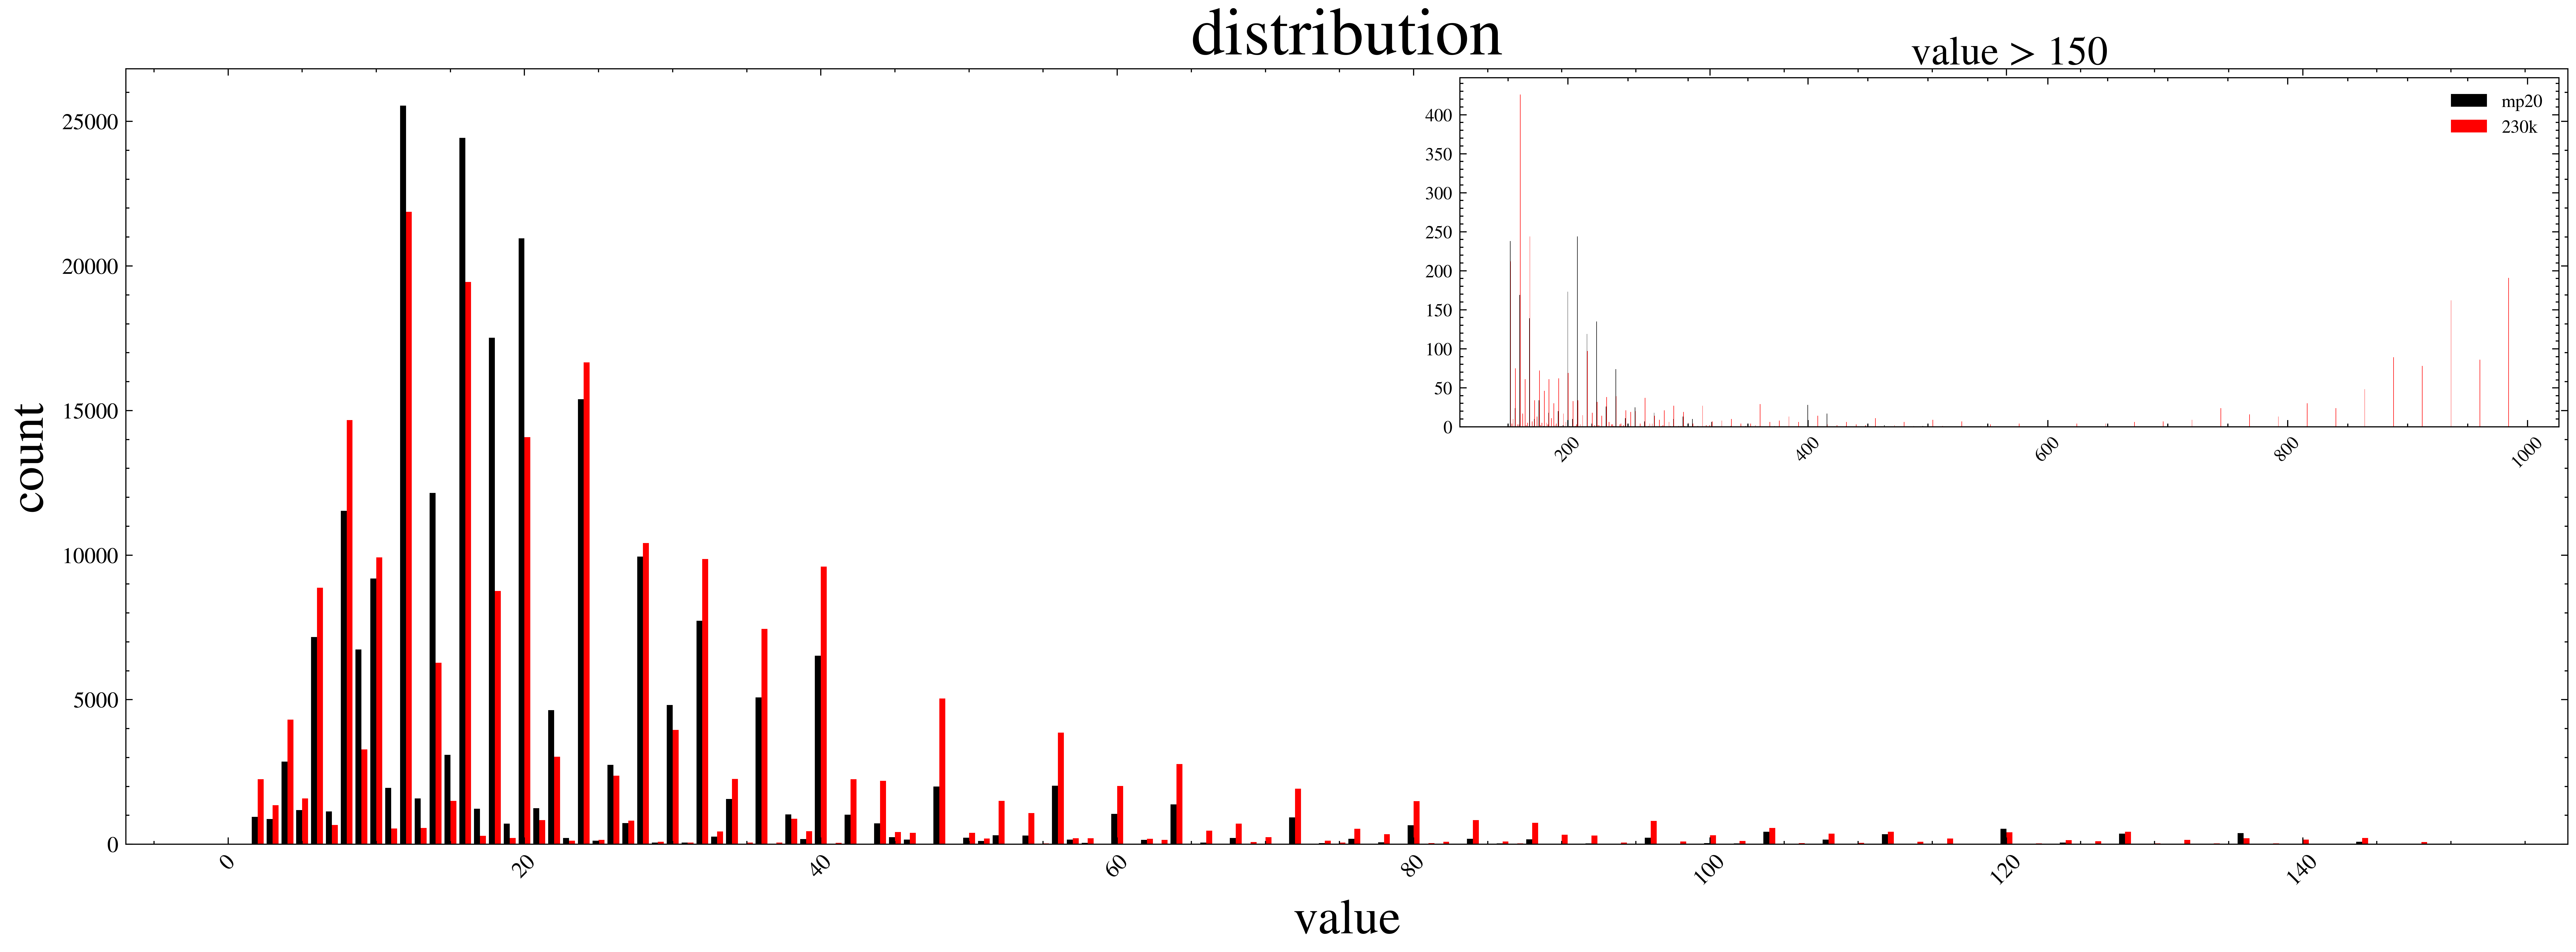

In [5]:
plot(((mp20_key, mp20_value, 'mp20'),(V1_key, v1_value, '230k')), threshold=150)

In [3]:
def compute_rate(df1, df2):
    df2_dict = df2.set_index('nsites')['counter'].to_dict()

    df1['rate'] = df1.apply(
        lambda row: row['counter'] / df2_dict[row['nsites']],
        axis=1)
    return df1['rate']

/public/home/wangqingchang/CrystalFormer/my_scripts/utils.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


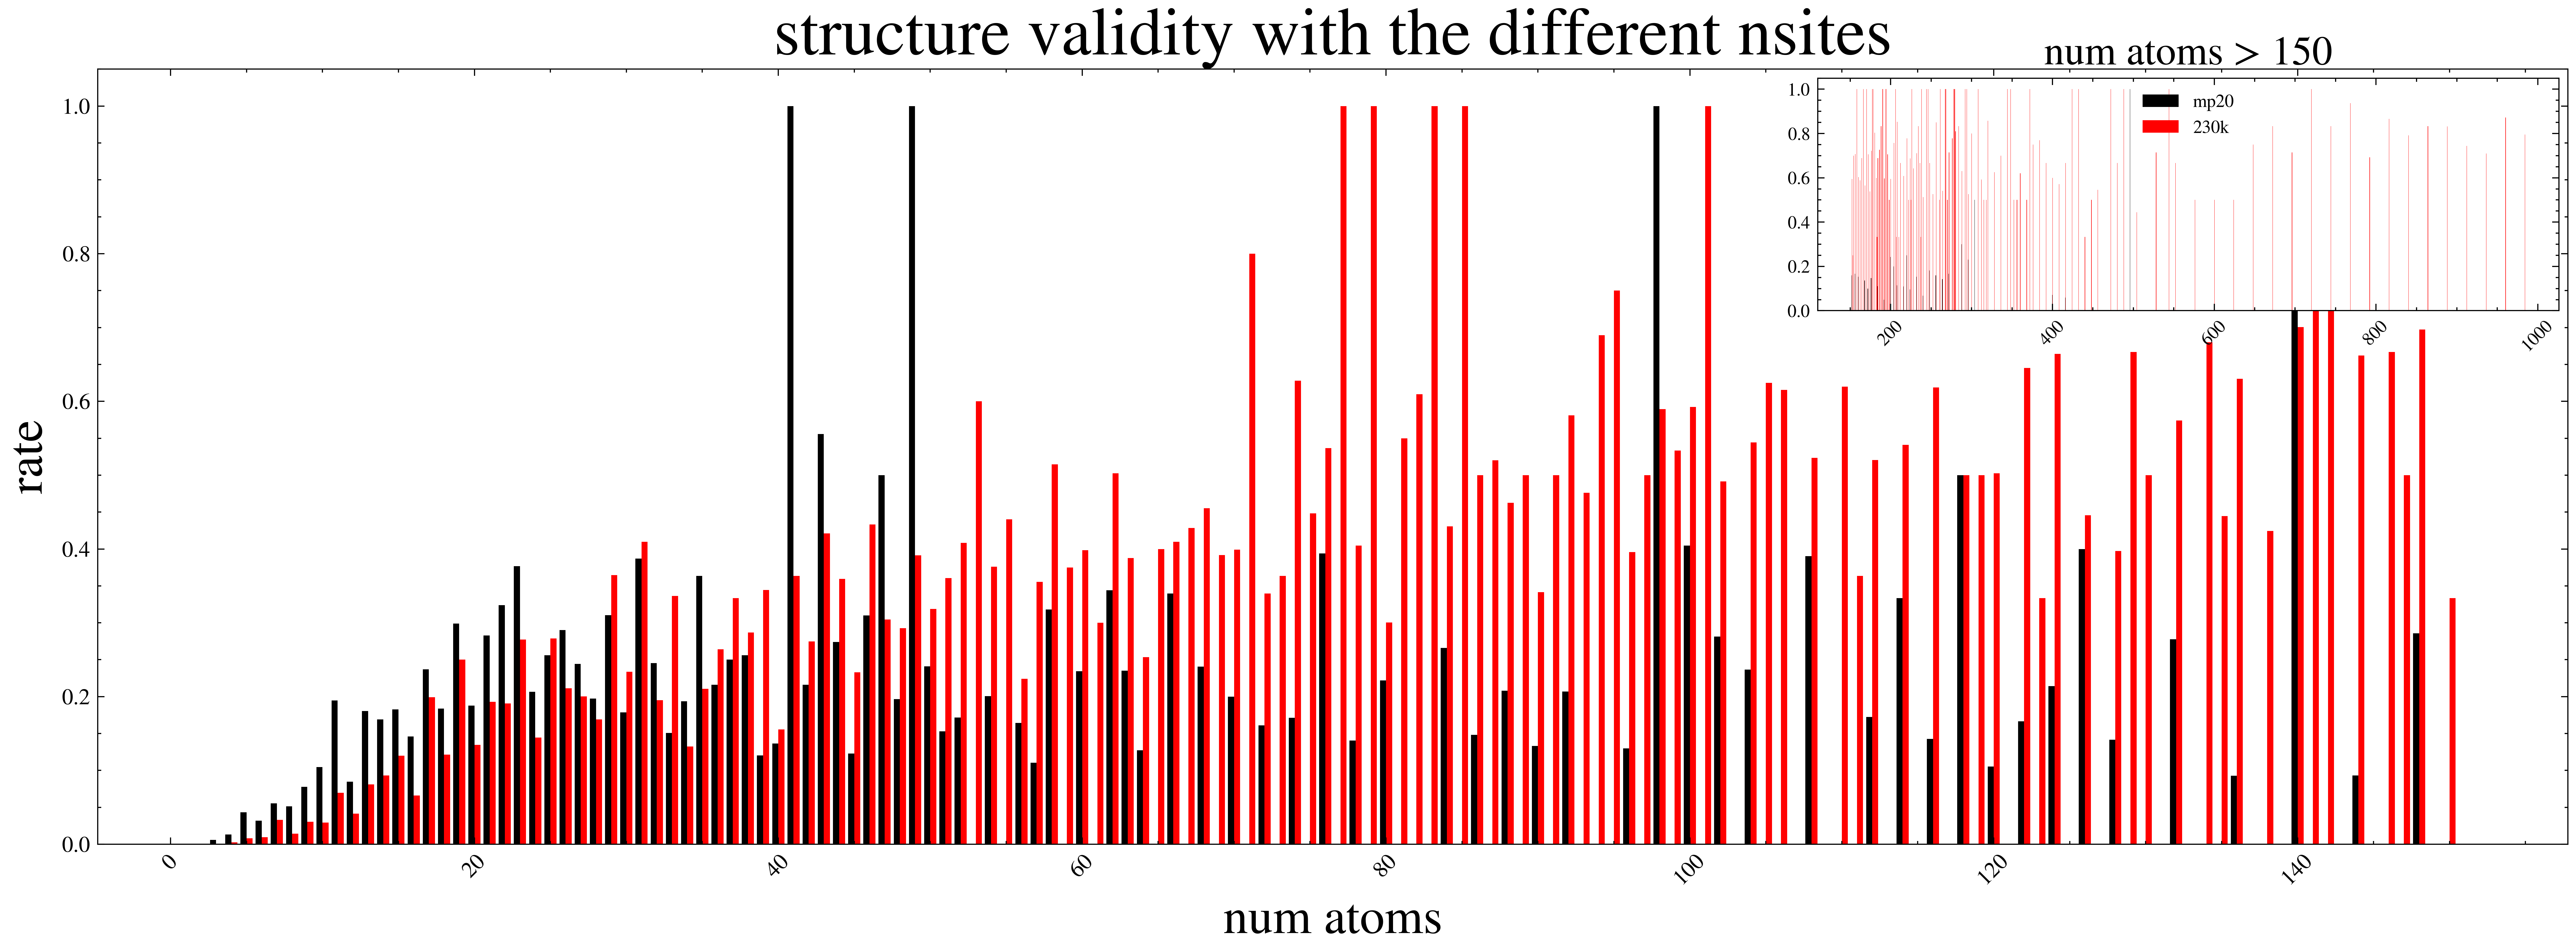

In [14]:
from utils import plot
import pandas as pd
#fs false sites
#aw all sites

as_mp20_path = "/public/home/wangqingchang/CrystalFormer/output/DSmp_20-adam-BS100-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.5/5200/again/nsites_dis.csv"
fs_mp20_path = "/public/home/wangqingchang/CrystalFormer/output/DSmp_20-adam-BS100-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.5/5200/again/false_nsites_dis.csv"
as_dV1_path = "/public/home/wangqingchang/CrystalFormer/output/DSaug_debug1-adam-BS128-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.3/9900/nsites_dis.csv"
fs_dV1_path = "/public/home/wangqingchang/CrystalFormer/output/DSaug_debug1-adam-BS128-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.3/9900/false_nsites_dis.csv"

df_fs_dV1 = pd.read_csv(fs_dV1_path)
df_fs_mp20 = pd.read_csv(fs_mp20_path)
df_as_dV1 = pd.read_csv(as_dV1_path)
df_as_mp20 = pd.read_csv(as_mp20_path)


fw_V1_key = df_fs_dV1['nsites']
fw_V1_value = compute_rate(df_fs_dV1, df_as_dV1)
fw_mp20_key = df_fs_mp20['nsites']
fw_mp20_value = compute_rate(df_fs_mp20, df_as_mp20)
plot(((fw_mp20_key, fw_mp20_value, 'mp20'),(fw_V1_key,fw_V1_value,'230k')),xlabel='num atoms', ylabel='rate',title='structure validity with the different nsites', threshold=150, ax_in_width="30%", ax_in_height="20%")

## plot spg 214

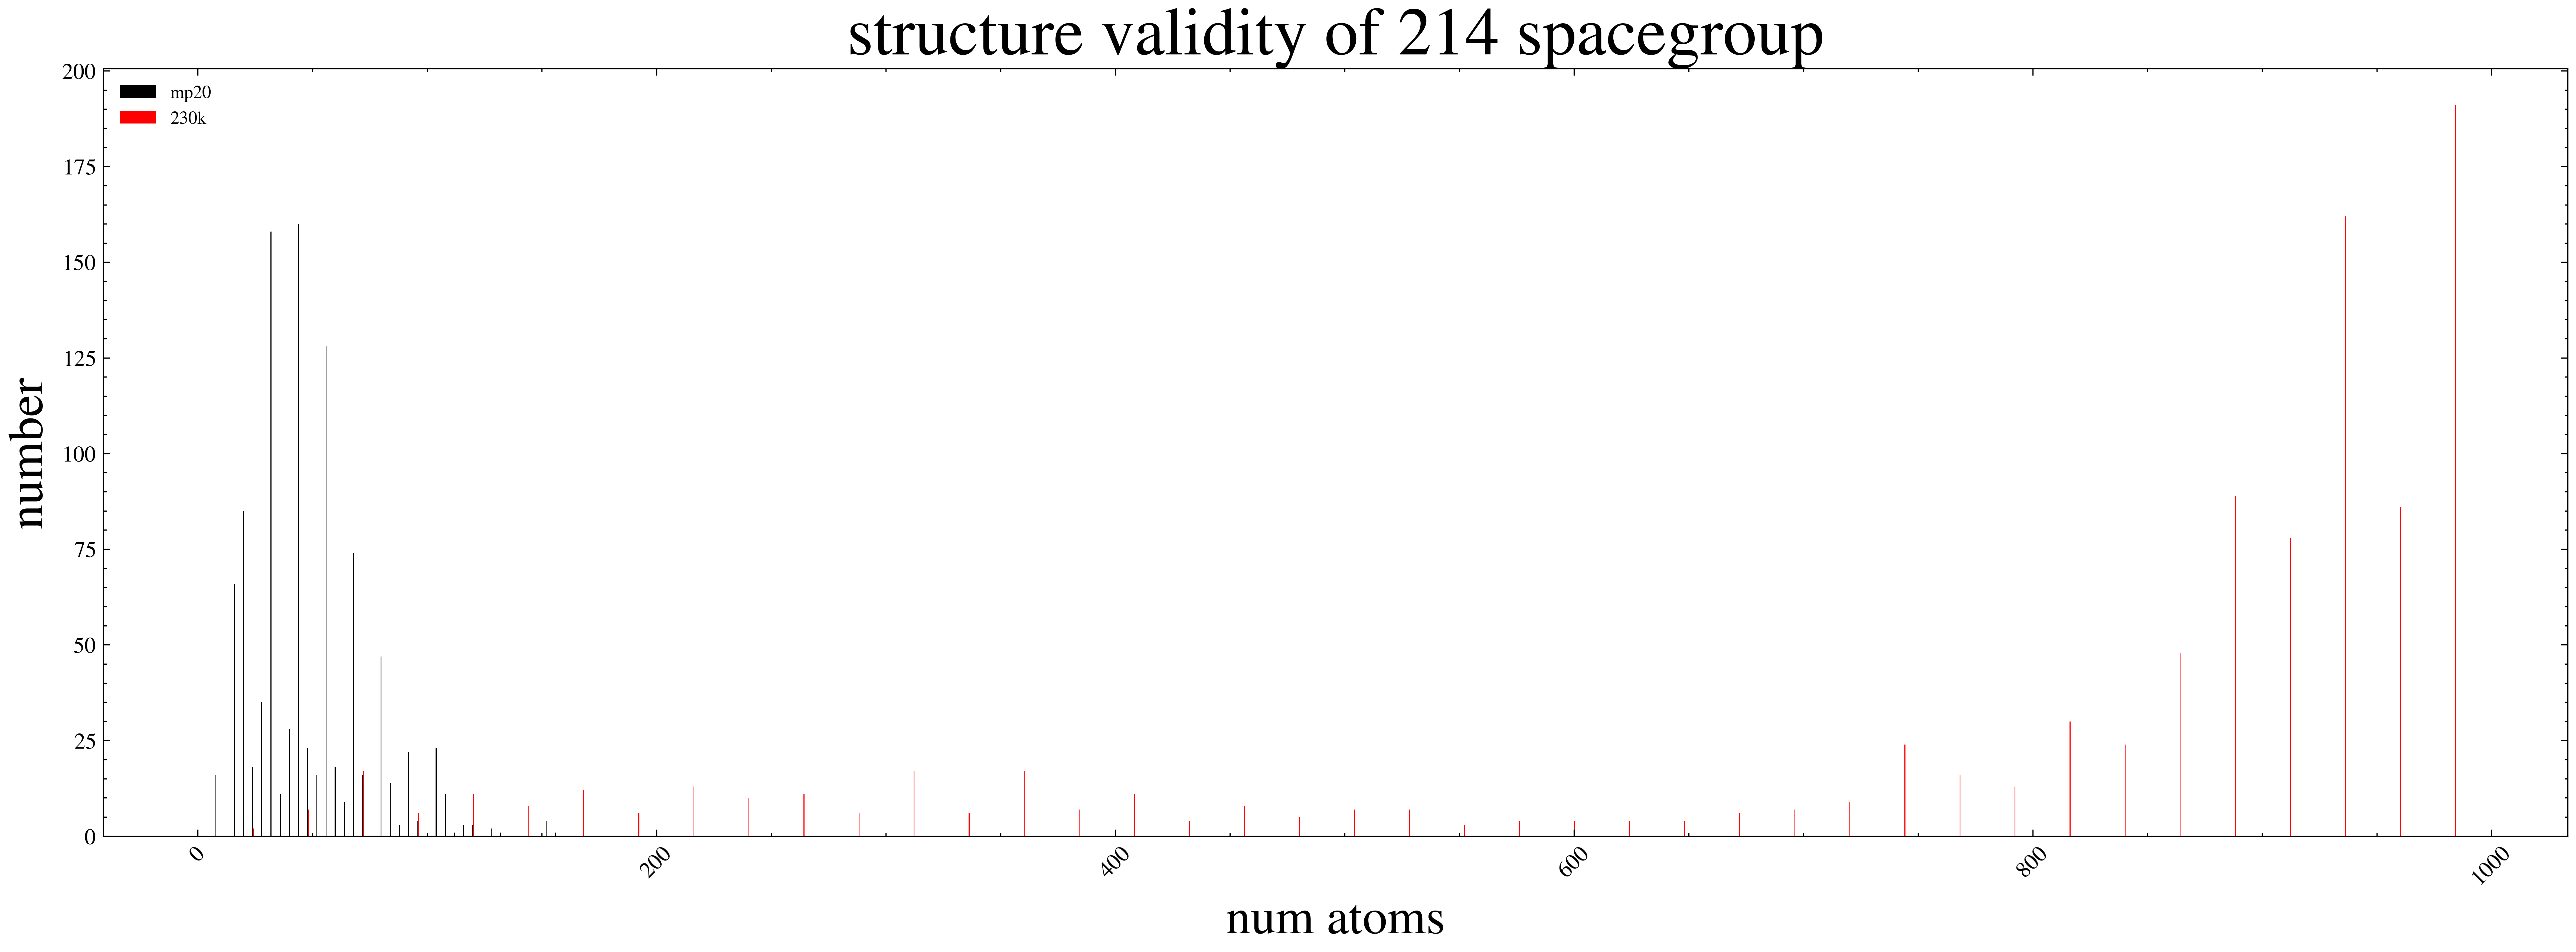

In [6]:
from utils import plot
import pandas as pd
df_214_dV1 = pd.read_csv("/public/home/wangqingchang/CrystalFormer/output/DSaug_debug1-adam-BS128-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.3/9900/214/nsites_dis.csv")
df_214_mp20 = pd.read_csv("/public/home/wangqingchang/CrystalFormer/output/DSmp_20-adam-BS100-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.5/5200/again/214/nsites_dis.csv")
k_dv1 = df_214_dV1['nsites']
v_dv1 =  df_214_dV1['counter']
k_mp20 = df_214_mp20['nsites']
v_mp20 = df_214_mp20['counter']
plot(((k_mp20 ,v_mp20 , 'mp20'), (k_dv1 ,v_dv1 , '230k')),xlabel='num atoms', ylabel='number',title='structure validity of 214 spacegroup', ax_in_width="30%", ax_in_height="20%")
#plot(((k_dv1 ,v_dv1 , '230k'),),xlabel='num atoms', ylabel='number',title='structure validity of 214 spacegroup', ax_in_width="30%", ax_in_height="20%")